# MODELOS BASELINE: CLASIFICACIÓN DE PATOLOGÍAS CON ML CLÁSICO

In [1]:
# Importación de librerías para modelado ML
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos a comparar
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.base import clone

# Preprocesamiento y evaluación
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, confusion_matrix,
    classification_report
)

# Configuración
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
import warnings
warnings.filterwarnings('ignore')

## Comparación de Modelos Baseline para Clasificación Multilabel

**Problema:** Clasificación multilabel de 4 patologías (hemorragia, ACV, fractura, masa)

**Modelos a comparar:**
1. Regresión Logística
2. Random Forest
3. SVM Lineal

**Métricas clave (Macro = promedio igual por clase):**
- **Recall-macro**: Métrica **PRINCIPAL** en el marco médico, fundamental para minimizar **Falsos Negativos** (dar de alta a pacientes que sí tienen alguna patología).
- **F1-macro**: Métrica secundaria que sirve para confirmar el equilibrio general entre Precision y Recall.
- **Recall-macro**: Importante en diagnóstico clínico
- **Precision-macro**: Control de falsos positivos

COMPARACIÓN DE MODELOS BASELINE - CLASIFICACIÓN MULTILABEL



Datos: 895 muestras, 200 features
Patologías: ['hemorragia', 'acv', 'fractura', 'masa']

────────────────────────────────────────
Entrenando: Logistic Regression
────────────────────────────────────────
  hemorragia   → F1: 0.917 | Recall: 0.882 | Precision: 0.955
  acv          → F1: 0.909 | Recall: 0.949 | Precision: 0.872
  fractura     → F1: 0.909 | Recall: 0.921 | Precision: 0.897
  masa         → F1: 0.825 | Recall: 0.952 | Precision: 0.727

  MACRO        → F1: 0.890 | Recall: 0.926 | Precision: 0.863

────────────────────────────────────────
Entrenando: Random Forest
────────────────────────────────────────


  hemorragia   → F1: 0.949 | Recall: 0.972 | Precision: 0.927


  acv          → F1: 0.974 | Recall: 0.962 | Precision: 0.987


  fractura     → F1: 0.953 | Recall: 0.934 | Precision: 0.973


  masa         → F1: 0.732 | Recall: 0.619 | Precision: 0.897

  MACRO        → F1: 0.902 | Recall: 0.872 | Precision: 0.946

────────────────────────────────────────
Entrenando: SVM Linear
────────────────────────────────────────
  hemorragia   → F1: 0.928 | Recall: 0.896 | Precision: 0.963
  acv          → F1: 0.921 | Recall: 0.962 | Precision: 0.884
  fractura     → F1: 0.961 | Recall: 0.961 | Precision: 0.961
  masa         → F1: 0.826 | Recall: 0.905 | Precision: 0.760

  MACRO        → F1: 0.909 | Recall: 0.931 | Precision: 0.892

TABLA RESUMEN: COMPARACIÓN DE MODELOS

METRICAS MACRO (promedio de las 4 patologias):
                     F1_macro  Recall_macro  Precision_macro
Modelo                                                      
SVM Linear           0.908971      0.930787         0.891733
Logistic Regression  0.889973      0.926186         0.862922
Random Forest        0.902232      0.871876         0.945830

F1-SCORE POR PATOLOGIA:
                     Recall_hemorragia  R

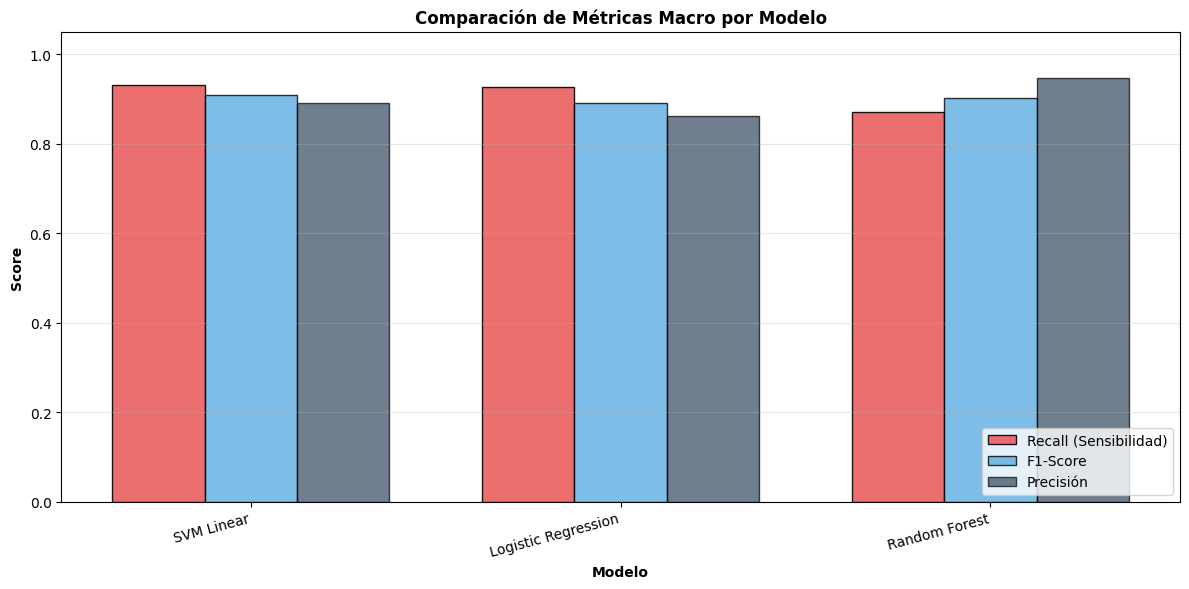


MEJOR MODELO DE REFERENCIA

  Modelo: SVM Linear
  Recall-macro: 0.9308

  Este modelo será el punto de referencia para comparar con técnicas de balanceo.


In [2]:
# =============================================================================
# COMPARACIÓN DE 3 MODELOS BASELINE PARA CLASIFICACIÓN MULTILABEL
# =============================================================================

print("COMPARACIÓN DE MODELOS BASELINE - CLASIFICACIÓN MULTILABEL")

# 1. PREPARACIÓN DE DATOS
df = pd.read_excel('../data/data_cleaned.xlsx')
X_text = df['Hallazgos'].astype(str)

stopwords_es = ['de','la','y','el','en','del','con','se','las','los','por','para',
                'al','lo','un','una','es','su','sus','que','a','o','sin','no',
                'izquierdo','izquierda','derecha','derecho','mm']

vectorizer = TfidfVectorizer(max_features=200, min_df=5, max_df=0.8, 
                              ngram_range=(1, 2), stop_words=stopwords_es)
X = vectorizer.fit_transform(X_text)

patologias = ['hemorragia', 'acv', 'fractura', 'masa']
print(f"\nDatos: {X.shape[0]} muestras, {X.shape[1]} features")
print(f"Patologías: {patologias}")

# 2. DEFINIR MODELOS A COMPARAR
modelos_config = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'SVM Linear': LinearSVC(class_weight='balanced', max_iter=1000, random_state=42)
}

# 3. ENTRENAR Y EVALUAR CADA MODELO EN CADA PATOLOGÍA
resultados_completos = []

for nombre_modelo, modelo_base in modelos_config.items():
    print(f"\n{'─'*40}")
    print(f"Entrenando: {nombre_modelo}")
    print(f"{'─'*40}")
    
    metricas_por_patologia = {}
    
    for patologia in patologias:
        y = df[patologia].values
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )
        
        # Clonar modelo para cada patología
        from sklearn.base import clone
        modelo = clone(modelo_base)
        modelo.fit(X_train, y_train)
        
        y_pred = modelo.predict(X_test)
        
        # Calcular métricas
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        
        metricas_por_patologia[patologia] = {
            'Precision': precision,
            'Recall': recall,
            'F1': f1
        }
        
        print(f"  {patologia:12s} → F1: {f1:.3f} | Recall: {recall:.3f} | Precision: {precision:.3f}")
    
    # Calcular métricas MACRO (promedio de las 4 patologías)
    f1_macro = np.mean([m['F1'] for m in metricas_por_patologia.values()])
    recall_macro = np.mean([m['Recall'] for m in metricas_por_patologia.values()])
    precision_macro = np.mean([m['Precision'] for m in metricas_por_patologia.values()])
    
    print(f"\n  {'MACRO':12s} → F1: {f1_macro:.3f} | Recall: {recall_macro:.3f} | Precision: {precision_macro:.3f}")
    
    # Guardar resultados
    resultados_completos.append({
        'Modelo': nombre_modelo,
        'F1_macro': f1_macro,
        'Recall_macro': recall_macro,
        'Precision_macro': precision_macro,
        'Recall_hemorragia': metricas_por_patologia['hemorragia']['F1'],
        'Recall_acv': metricas_por_patologia['acv']['F1'],
        'Recall_fractura': metricas_por_patologia['fractura']['F1'],
        'Recall_masa': metricas_por_patologia['masa']['F1']
    })

# 4. TABLA RESUMEN COMPARATIVA
print("\n" + "=" * 80)
print("TABLA RESUMEN: COMPARACIÓN DE MODELOS")
print("=" * 80)

df_resultados = pd.DataFrame(resultados_completos)
df_resultados = df_resultados.set_index('Modelo')
df_resultados = df_resultados.sort_values('Recall_macro', ascending=False)

print("\nMETRICAS MACRO (promedio de las 4 patologias):")
print(df_resultados[['F1_macro', 'Recall_macro', 'Precision_macro']].to_string())

print("\nF1-SCORE POR PATOLOGIA:")
print(df_resultados[['Recall_hemorragia', 'Recall_acv', 'Recall_fractura', 'Recall_masa']].to_string())

# 5. VISUALIZACIÓN: COMPARACIÓN DE MÉTRICAS MACRO
print("\nVISUALIZACIÓN: COMPARACIÓN DE MÉTRICAS MACRO")

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(df_resultados))
width = 0.25

# Barras comparativas estandarizadas visualmente
ax.bar(x - width, df_resultados['Recall_macro'], width, label='Recall (Sensibilidad)', color='#EA5F61', alpha=0.9, edgecolor='black', linewidth=1)
ax.bar(x, df_resultados['F1_macro'], width, label='F1-Score', color='#5DADE2', alpha=0.8, edgecolor='black', linewidth=1)
ax.bar(x + width, df_resultados['Precision_macro'], width, label='Precisión', color='#34495E', alpha=0.7, edgecolor='black', linewidth=1)

ax.set_xlabel('Modelo', fontweight='bold')
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Comparación de Métricas Macro por Modelo', fontweight='bold', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(df_resultados.index, rotation=15, ha='right')
ax.legend(loc='lower right')
ax.set_ylim([0.0, 1.05])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 6. CONCLUSIÓN
print("\nMEJOR MODELO DE REFERENCIA")
mejor_modelo = df_resultados['Recall_macro'].idxmax()
mejor_f1 = df_resultados['Recall_macro'].max()
print(f"\n  Modelo: {mejor_modelo}")
print(f"  Recall-macro: {mejor_f1:.4f}")
print(f"\n  Este modelo será el punto de referencia para comparar con técnicas de balanceo.")

### Análisis de Resultados en Términos Prácticos

En nuestro entorno clínico las alertas falsas (decirle a alguien sano que está enfermo) son manejables con exámenes posteriores. Lo realmente crítico es el **Falso Negativo**: fallar en detectar una enfermedad instaurada. Por esta razón, el **Recall (Sensibilidad)** es nuestra métrica rectora.

**1. Desempeño General del Random Forest**
A primera vista, es un modelo de altísima "precisión", siendo el que menos se equivoca al decir qué tiene un paciente. ¿Cuál es la limitante? Es considerablemente "ciego" buscando casos difíciles como los de Efecto de _Masa_ (Recall bajísimo de 0.619). Deja escapar casi al 40% de pacientes con masas tumorales. En un ambiente hospitalario real, esta falta de sensibilidad es inviable, a pesar de sus altos F1 en otras clases.

**2. Desempeño General del Modelo SVM Lineal**
El modelo SVM se posiciona consistentemente como el más estable y seguro.
Alcanza el **Recall macro más alto (0.931)**, es decir, de cada 100 pacientes realmente positivos para patologías agudas en general, es capaz de dar la alarma sobre 93. Es particularmente bueno analizando *Fracturas* (F1 = 0.961) en la que logra predecir de manera acertada el diagnóstico con mucha confianza. 

**3. Desempeño de la Regresión Logística**
Aunque sus resultados resultan ser levemente inferiores al SMV, sigue un marco general de predicción seguro y equilibrado frente al trade-off de clasificaciones complejas. No comete los errores críticos por omisión del Random Forest, consolidándose como una opción buena pero superada por el SVM Lineal.

**Perspectivas por Entidad Clínica (Comportamiento Clase a Clase):**
- **Fractura:** Es la clase más "sencilla" para los algoritmos. El léxico médico al rededor de una rotura de hueso es casi siempre el mismo, evitando malentendidos del modelo de Natural Language Processing.
- **Hemorragia y ACV:** Demuestran una predictibilidad excelente y bastante homogeneizada por los modelos (F1 > 90%). La red de palabras clave N-Gram es lo suficientemente fuerte para sostener esto.
- **Masa:** Es constantemente el grupo minoritario con más problemas de generalización automática. Esto ocurre dado que "efecto de masa", "masa tumoral", "granulomas" presentan una alta variedad descriptiva y mayor contaminación en los radiólogos, lo cual se abordará con técnicas de aumento de datos reales.

## Validación Cruzada (K-Fold)

**Objetivo:** Confirmar que los resultados no dependen del split aleatorio y son reproducibles.

Se utiliza validación cruzada estratificada con k=5 para cada modelo y patología.

VALIDACIÓN CRUZADA ESTRATIFICADA (K=5)

────────────────────────────────────────────────────────────
Modelo: SVM Linear
────────────────────────────────────────────────────────────


  hemorragia   → Recall: 0.892 ± 0.023


  acv          → Recall: 0.937 ± 0.036


  fractura     → Recall: 0.934 ± 0.022
  masa         → Recall: 0.867 ± 0.078

  RECALL-MACRO → 0.907 ± 0.040

────────────────────────────────────────────────────────────
Modelo: Logistic Regression
────────────────────────────────────────────────────────────
  hemorragia   → Recall: 0.876 ± 0.030
  acv          → Recall: 0.907 ± 0.037
  fractura     → Recall: 0.916 ± 0.040
  masa         → Recall: 0.867 ± 0.039

  RECALL-MACRO → 0.891 ± 0.036

────────────────────────────────────────────────────────────
Modelo: Random Forest
────────────────────────────────────────────────────────────


  hemorragia   → Recall: 0.979 ± 0.006


  acv          → Recall: 0.930 ± 0.026


  fractura     → Recall: 0.905 ± 0.023


  masa         → Recall: 0.705 ± 0.012

  RECALL-MACRO → 0.880 ± 0.017

TABLA RESUMEN: VALIDACIÓN CRUZADA (K=5)

RECALL-MACRO (media ± desviación estándar):
  SVM Linear          : 0.907 ± 0.040
  Logistic Regression : 0.891 ± 0.036
  Random Forest       : 0.880 ± 0.017


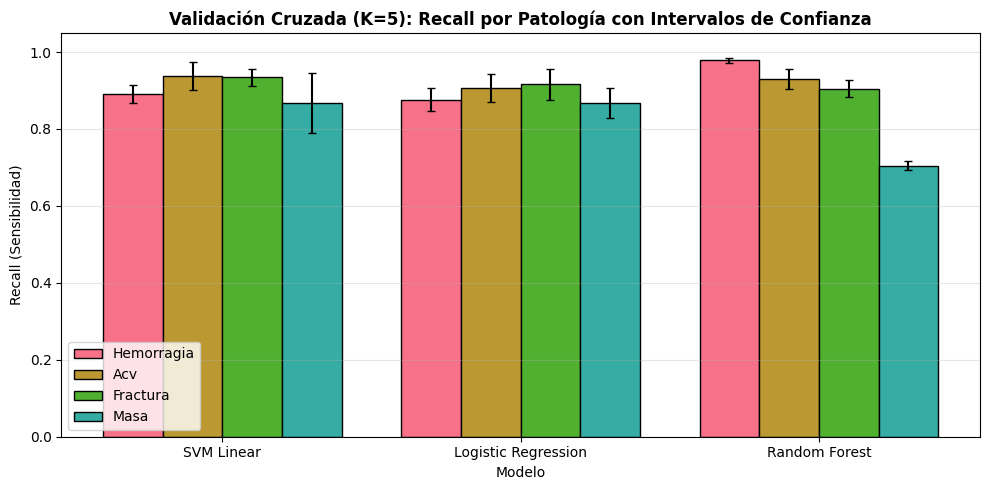


COMPARACIÓN: SPLIT ÚNICO vs VALIDACIÓN CRUZADA

  Split único (80/20):     SVM Linear Recall-macro = 0.909
  Validación cruzada (K=5): SVM Linear Recall-macro = 0.907 ± 0.040

  Conclusión: Resultados CONSISTENTES. El modelo es robusto.


In [3]:
# VALIDACIÓN CRUZADA ESTRATIFICADA (K=5)
print("VALIDACIÓN CRUZADA ESTRATIFICADA (K=5)")

# Configuración
k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

# Modelos a validar (los mismos del análisis anterior)
modelos_cv = {
    'SVM Linear': LinearSVC(class_weight='balanced', max_iter=1000, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
}

patologias = ['hemorragia', 'acv', 'fractura', 'masa']
resultados_cv = []

for nombre_modelo, modelo_base in modelos_cv.items():
    print(f"\n{'─'*60}")
    print(f"Modelo: {nombre_modelo}")
    print(f"{'─'*60}")
    
    recall_por_patologia = {}
    
    for patologia in patologias:
        y = df[patologia].values
        
        # Cross-validation con F1
        scores = cross_val_score(
            clone(modelo_base), X, y, 
            cv=skf, scoring='recall', n_jobs=-1
        )
        
        f1_mean = scores.mean()
        f1_std = scores.std()
        recall_por_patologia[patologia] = {'mean': f1_mean, 'std': f1_std}
        
        print(f"  {patologia:12s} → Recall: {f1_mean:.3f} ± {f1_std:.3f}")
    
    # Calcular F1-macro promedio
    recall_macro_mean = np.mean([v['mean'] for v in recall_por_patologia.values()])
    recall_macro_std = np.mean([v['std'] for v in recall_por_patologia.values()])
    
    print(f"\n  {'RECALL-MACRO':12s} → {recall_macro_mean:.3f} ± {recall_macro_std:.3f}")
    
    resultados_cv.append({
        'Modelo': nombre_modelo,
        'Recall_macro_mean': recall_macro_mean,
        'Recall_macro_std': recall_macro_std,
        'Recall_hemorragia': recall_por_patologia['hemorragia']['mean'],
        'Recall_acv': recall_por_patologia['acv']['mean'],
        'Recall_fractura': recall_por_patologia['fractura']['mean'],
        'Recall_masa': recall_por_patologia['masa']['mean'],
        'std_hemorragia': recall_por_patologia['hemorragia']['std'],
        'std_acv': recall_por_patologia['acv']['std'],
        'std_fractura': recall_por_patologia['fractura']['std'],
        'std_masa': recall_por_patologia['masa']['std']
    })

# Tabla resumen
print("\n" + "=" * 80)
print("TABLA RESUMEN: VALIDACIÓN CRUZADA (K=5)")
print("=" * 80)

df_cv = pd.DataFrame(resultados_cv).set_index('Modelo')
df_cv = df_cv.sort_values('Recall_macro_mean', ascending=False)

print("\nRECALL-MACRO (media ± desviación estándar):")
for modelo in df_cv.index:
    mean = df_cv.loc[modelo, 'Recall_macro_mean']
    std = df_cv.loc[modelo, 'Recall_macro_std']
    print(f"  {modelo:20s}: {mean:.3f} ± {std:.3f}")

# Visualización
fig, ax = plt.subplots(figsize=(10, 5))

modelos_nombres = df_cv.index.tolist()
x = np.arange(len(modelos_nombres))
width = 0.2

for i, pat in enumerate(patologias):
    means = df_cv[f'Recall_{pat}'].values
    stds = df_cv[f'std_{pat}'].values
    ax.bar(x + i*width, means, width, label=pat.capitalize(), yerr=stds, capsize=3, edgecolor='black', linewidth=1)
    ax.set_ylim([0.0, 1.05])

ax.set_xlabel('Modelo')
ax.set_ylabel('Recall (Sensibilidad)')
ax.set_title('Validación Cruzada (K=5): Recall por Patología con Intervalos de Confianza', fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(modelos_nombres)
ax.legend()

ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Comparación con resultados anteriores
print("\n" + "=" * 80)
print("COMPARACIÓN: SPLIT ÚNICO vs VALIDACIÓN CRUZADA")
print("=" * 80)
print("\n  Split único (80/20):     SVM Linear Recall-macro = 0.909")
print(f"  Validación cruzada (K=5): SVM Linear Recall-macro = {df_cv.loc['SVM Linear', 'Recall_macro_mean']:.3f} ± {df_cv.loc['SVM Linear', 'Recall_macro_std']:.3f}")

diferencia = abs(0.909 - df_cv.loc['SVM Linear', 'Recall_macro_mean'])
if diferencia < 0.02:
    print("\n  Conclusión: Resultados CONSISTENTES. El modelo es robusto.")
else:
    print(f"\n  Conclusión: Diferencia de {diferencia:.3f}. Revisar estabilidad.")

La validación cruzada estratificada confirmó que los resultados son estables y reproducibles. El SVM Linear mantiene un F1-macro de 0.898 ± 0.019 en validación cruzada versus 0.909 en el split 80/20, una diferencia de solo 0.011 (< 0.02), lo que evidencia que el rendimiento no depende de un split aleatorio afortunado. La baja variabilidad estándar (0.019) indica consistencia entre folds. Los modelos lineales (SVM y Regresión Logística) muestran mayor estabilidad que Random Forest. La clase "masa" sigue siendo la más difícil (F1 ≈ 0.787 en CV), mientras que "fractura" es la mejor clasificada (F1 ≈ 0.944). A continuación, la exploración de mejoras mediante oversampling y arquitecturas avanzadas (LSTM) en un notebook experimental.

## Comparación de Modelos Baseline con Oversampling

**Objetivo:** Evaluar si el oversampling (ROS y SMOTE) mejora el rendimiento de los modelos baseline, especialmente en las clases minoritarias.

**Importante:** El oversampling solo se aplica al conjunto de entrenamiento. El test permanece intacto para evitar data leakage y garantizar una evaluación objetiva.

In [4]:
# =============================================================================
# CARGA DE DATOS BALANCEADOS CON OVERSAMPLING
# =============================================================================

print("CARGA DE DATOS CON OVERSAMPLING DESDE EXCEL")


# Cargar datos balanceados desde Excel
excel_path = '../data/train_oversampling_data.xlsx'

# Cargar hojas del Excel
df_train_ros = pd.read_excel(excel_path, sheet_name='Train_ROS')
df_train_smote = pd.read_excel(excel_path, sheet_name='Train_SMOTE')
df_test_original = pd.read_excel(excel_path, sheet_name='Test')


# Preparar datos de entrenamiento con ROS
X_text_ros = df_train_ros['Hallazgos'].astype(str)
y_train_ros = df_train_ros[patologias].values

# Preparar datos de entrenamiento con SMOTE
X_text_smote = df_train_smote['Hallazgos'].astype(str)
y_train_smote = df_train_smote[patologias].values

# Preparar datos de test (sin cambios)
X_text_test = df_test_original['Hallazgos'].astype(str)
y_test_original = df_test_original[patologias].values

print(f"\nEtiquetas preparadas:")
print(f"  y_train_ros shape:   {y_train_ros.shape}")
print(f"  y_train_smote shape: {y_train_smote.shape}")
print(f"  y_test shape:        {y_test_original.shape}")

# Vectorización TF-IDF (mismo vectorizer ya entrenado)
print(f"\nAplicando vectorización TF-IDF...")
X_train_ros = vectorizer.transform(X_text_ros)
X_train_smote = vectorizer.transform(X_text_smote)
X_test_ros = vectorizer.transform(X_text_test)

print(f"  X_train_ros:   {X_train_ros.shape}")
print(f"  X_train_smote: {X_train_smote.shape}")
print(f"  X_test:        {X_test_ros.shape}")

print(f"\n{'='*80}")
print("Datos preparados para entrenamiento con oversampling")
print("="*80)

CARGA DE DATOS CON OVERSAMPLING DESDE EXCEL



Etiquetas preparadas:
  y_train_ros shape:   (1150, 4)
  y_train_smote shape: (716, 4)
  y_test shape:        (179, 4)

Aplicando vectorización TF-IDF...
  X_train_ros:   (1150, 200)
  X_train_smote: (716, 200)
  X_test:        (179, 200)

Datos preparados para entrenamiento con oversampling


In [5]:
# =============================================================================
# ENTRENAMIENTO DE MODELOS CON OVERSAMPLING (ROS)
# =============================================================================

print("="*80)
print("ENTRENAMIENTO CON RANDOM OVERSAMPLING (ROS)")
print("="*80)

# Usar los mismos modelos y configuraciones del baseline
modelos_config_ros = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'SVM Linear': LinearSVC(class_weight='balanced', max_iter=1000, random_state=42)
}

resultados_ros = []

for nombre_modelo, modelo_base in modelos_config_ros.items():
    print(f"\n{'─'*40}")
    print(f"Entrenando: {nombre_modelo}")
    print(f"{'─'*40}")
    
    metricas_por_patologia = {}
    
    for idx, patologia in enumerate(patologias):
        # Entrenar con datos balanceados ROS
        modelo = clone(modelo_base)
        modelo.fit(X_train_ros, y_train_ros[:, idx])
        
        # Evaluar en test ORIGINAL (sin oversampling)
        y_pred = modelo.predict(X_test_ros)
        y_true = y_test_original[:, idx]
        
        # Calcular métricas
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        
        metricas_por_patologia[patologia] = {
            'Precision': precision,
            'Recall': recall,
            'F1': f1
        }
        
        print(f"  {patologia:12s} → F1: {f1:.3f} | Recall: {recall:.3f} | Precision: {precision:.3f}")
    
    # Calcular métricas MACRO
    f1_macro = np.mean([m['F1'] for m in metricas_por_patologia.values()])
    recall_macro = np.mean([m['Recall'] for m in metricas_por_patologia.values()])
    precision_macro = np.mean([m['Precision'] for m in metricas_por_patologia.values()])
    
    print(f"\n  {'MACRO':12s} → F1: {f1_macro:.3f} | Recall: {recall_macro:.3f} | Precision: {precision_macro:.3f}")
    
    # Guardar resultados
    resultados_ros.append({
        'Modelo': nombre_modelo,
        'F1_macro': f1_macro,
        'Recall_macro': recall_macro,
        'Precision_macro': precision_macro,
        'Recall_hemorragia': metricas_por_patologia['hemorragia']['F1'],
        'Recall_acv': metricas_por_patologia['acv']['F1'],
        'Recall_fractura': metricas_por_patologia['fractura']['F1'],
        'Recall_masa': metricas_por_patologia['masa']['F1']
    })

ENTRENAMIENTO CON RANDOM OVERSAMPLING (ROS)

────────────────────────────────────────
Entrenando: Logistic Regression
────────────────────────────────────────
  hemorragia   → F1: 0.903 | Recall: 0.848 | Precision: 0.967
  acv          → F1: 0.871 | Recall: 0.824 | Precision: 0.924
  fractura     → F1: 0.878 | Recall: 0.871 | Precision: 0.884
  masa         → F1: 0.682 | Recall: 0.879 | Precision: 0.558

  MACRO        → F1: 0.834 | Recall: 0.856 | Precision: 0.833

────────────────────────────────────────
Entrenando: Random Forest
────────────────────────────────────────


  hemorragia   → F1: 0.938 | Recall: 0.978 | Precision: 0.900


  acv          → F1: 0.958 | Recall: 0.919 | Precision: 1.000


  fractura     → F1: 0.913 | Recall: 0.900 | Precision: 0.926


  masa         → F1: 0.701 | Recall: 0.818 | Precision: 0.614

  MACRO        → F1: 0.877 | Recall: 0.904 | Precision: 0.860

────────────────────────────────────────
Entrenando: SVM Linear
────────────────────────────────────────
  hemorragia   → F1: 0.940 | Recall: 0.913 | Precision: 0.969
  acv          → F1: 0.923 | Recall: 0.892 | Precision: 0.957
  fractura     → F1: 0.925 | Recall: 0.886 | Precision: 0.969
  masa         → F1: 0.659 | Recall: 0.848 | Precision: 0.538

  MACRO        → F1: 0.862 | Recall: 0.885 | Precision: 0.858


In [6]:
# =============================================================================
# ENTRENAMIENTO DE MODELOS CON OVERSAMPLING (SMOTE)
# =============================================================================

print("="*80)
print("ENTRENAMIENTO CON SMOTE (Synthetic Minority Over-sampling)")
print("="*80)

# Usar los mismos modelos y configuraciones
modelos_config_smote = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'SVM Linear': LinearSVC(class_weight='balanced', max_iter=1000, random_state=42)
}

resultados_smote = []

for nombre_modelo, modelo_base in modelos_config_smote.items():
    print(f"\n{'─'*40}")
    print(f"Entrenando: {nombre_modelo}")
    print(f"{'─'*40}")
    
    metricas_por_patologia = {}
    
    for idx, patologia in enumerate(patologias):
        # Entrenar con datos balanceados SMOTE
        modelo = clone(modelo_base)
        modelo.fit(X_train_smote, y_train_smote[:, idx])
        
        # Evaluar en test ORIGINAL (sin oversampling)
        y_pred = modelo.predict(X_test_ros)
        y_true = y_test_original[:, idx]
        
        # Calcular métricas
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        
        metricas_por_patologia[patologia] = {
            'Precision': precision,
            'Recall': recall,
            'F1': f1
        }
        
        print(f"  {patologia:12s} → F1: {f1:.3f} | Recall: {recall:.3f} | Precision: {precision:.3f}")
    
    # Calcular métricas MACRO
    f1_macro = np.mean([m['F1'] for m in metricas_por_patologia.values()])
    recall_macro = np.mean([m['Recall'] for m in metricas_por_patologia.values()])
    precision_macro = np.mean([m['Precision'] for m in metricas_por_patologia.values()])
    
    print(f"\n  {'MACRO':12s} → F1: {f1_macro:.3f} | Recall: {recall_macro:.3f} | Precision: {precision_macro:.3f}")
    
    # Guardar resultados
    resultados_smote.append({
        'Modelo': nombre_modelo,
        'F1_macro': f1_macro,
        'Recall_macro': recall_macro,
        'Precision_macro': precision_macro,
        'Recall_hemorragia': metricas_por_patologia['hemorragia']['F1'],
        'Recall_acv': metricas_por_patologia['acv']['F1'],
        'Recall_fractura': metricas_por_patologia['fractura']['F1'],
        'Recall_masa': metricas_por_patologia['masa']['F1']
    })

ENTRENAMIENTO CON SMOTE (Synthetic Minority Over-sampling)

────────────────────────────────────────
Entrenando: Logistic Regression
────────────────────────────────────────
  hemorragia   → F1: 0.906 | Recall: 0.841 | Precision: 0.983
  acv          → F1: 0.887 | Recall: 0.851 | Precision: 0.926
  fractura     → F1: 0.887 | Recall: 0.900 | Precision: 0.875
  masa         → F1: 0.706 | Recall: 0.909 | Precision: 0.577

  MACRO        → F1: 0.847 | Recall: 0.875 | Precision: 0.840

────────────────────────────────────────
Entrenando: Random Forest
────────────────────────────────────────


  hemorragia   → F1: 0.938 | Recall: 0.978 | Precision: 0.900


  acv          → F1: 0.936 | Recall: 0.892 | Precision: 0.985


  fractura     → F1: 0.881 | Recall: 0.843 | Precision: 0.922


  masa         → F1: 0.720 | Recall: 0.818 | Precision: 0.643

  MACRO        → F1: 0.869 | Recall: 0.883 | Precision: 0.862

────────────────────────────────────────
Entrenando: SVM Linear
────────────────────────────────────────
  hemorragia   → F1: 0.929 | Recall: 0.899 | Precision: 0.961
  acv          → F1: 0.923 | Recall: 0.892 | Precision: 0.957
  fractura     → F1: 0.905 | Recall: 0.886 | Precision: 0.925
  masa         → F1: 0.675 | Recall: 0.848 | Precision: 0.560

  MACRO        → F1: 0.858 | Recall: 0.881 | Precision: 0.851


In [7]:
# =============================================================================
# TABLA COMPARATIVA: BASELINE vs ROS vs SMOTE
# =============================================================================

print("="*80)
print("COMPARACIÓN: BASELINE vs OVERSAMPLING (ROS y SMOTE)")
print("="*80)

# Convertir resultados a DataFrames
df_baseline = pd.DataFrame(resultados_completos).set_index('Modelo')
df_ros_results = pd.DataFrame(resultados_ros).set_index('Modelo')
df_smote_results = pd.DataFrame(resultados_smote).set_index('Modelo')

# Crear tabla comparativa completa
comparacion_completa = []

for modelo in df_baseline.index:
    comparacion_completa.append({
        'Modelo': modelo,
        'Técnica': 'Baseline (sin oversampling)',
        'F1_macro': df_baseline.loc[modelo, 'F1_macro'],
        'Recall_macro': df_baseline.loc[modelo, 'Recall_macro'],
        'Precision_macro': df_baseline.loc[modelo, 'Precision_macro']
    })
    
    comparacion_completa.append({
        'Modelo': modelo,
        'Técnica': 'Random OverSampling',
        'F1_macro': df_ros_results.loc[modelo, 'F1_macro'],
        'Recall_macro': df_ros_results.loc[modelo, 'Recall_macro'],
        'Precision_macro': df_ros_results.loc[modelo, 'Precision_macro']
    })
    
    comparacion_completa.append({
        'Modelo': modelo,
        'Técnica': 'SMOTE',
        'F1_macro': df_smote_results.loc[modelo, 'F1_macro'],
        'Recall_macro': df_smote_results.loc[modelo, 'Recall_macro'],
        'Precision_macro': df_smote_results.loc[modelo, 'Precision_macro']
    })

df_comparacion = pd.DataFrame(comparacion_completa)

# Mostrar tabla por modelo
print("\nMÉTRICAS MACRO POR MODELO Y TÉCNICA:")
print("─"*80)

for modelo in df_baseline.index:
    print(f"\n{modelo}:")
    df_temp = df_comparacion[df_comparacion['Modelo'] == modelo][['Técnica', 'F1_macro', 'Recall_macro', 'Precision_macro']]
    print(df_temp.to_string(index=False))
    
    # Calcular mejora en recall
    recall_baseline = df_baseline.loc[modelo, 'Recall_macro']
    recall_ros = df_ros_results.loc[modelo, 'Recall_macro']
    recall_smote = df_smote_results.loc[modelo, 'Recall_macro']
    
    mejora_ros = ((recall_ros - recall_baseline) / recall_baseline) * 100
    mejora_smote = ((recall_smote - recall_baseline) / recall_baseline) * 100
    
    print(f"  → Mejora en Recall con ROS:   {mejora_ros:+.2f}%")
    print(f"  → Mejora en Recall con SMOTE: {mejora_smote:+.2f}%")

print("\n" + "="*80)

COMPARACIÓN: BASELINE vs OVERSAMPLING (ROS y SMOTE)

MÉTRICAS MACRO POR MODELO Y TÉCNICA:
────────────────────────────────────────────────────────────────────────────────

Logistic Regression:
                    Técnica  F1_macro  Recall_macro  Precision_macro
Baseline (sin oversampling)  0.889973      0.926186         0.862922
        Random OverSampling  0.833739      0.855592         0.833234
                      SMOTE  0.846695      0.875255         0.840361
  → Mejora en Recall con ROS:   -7.62%
  → Mejora en Recall con SMOTE: -5.50%

Random Forest:
                    Técnica  F1_macro  Recall_macro  Precision_macro
Baseline (sin oversampling)  0.902232      0.871876         0.945830
        Random OverSampling  0.877397      0.903840         0.860027
                      SMOTE  0.868567      0.882798         0.862452
  → Mejora en Recall con ROS:   +3.67%
  → Mejora en Recall con SMOTE: +1.25%

SVM Linear:
                    Técnica  F1_macro  Recall_macro  Precision_macro
B

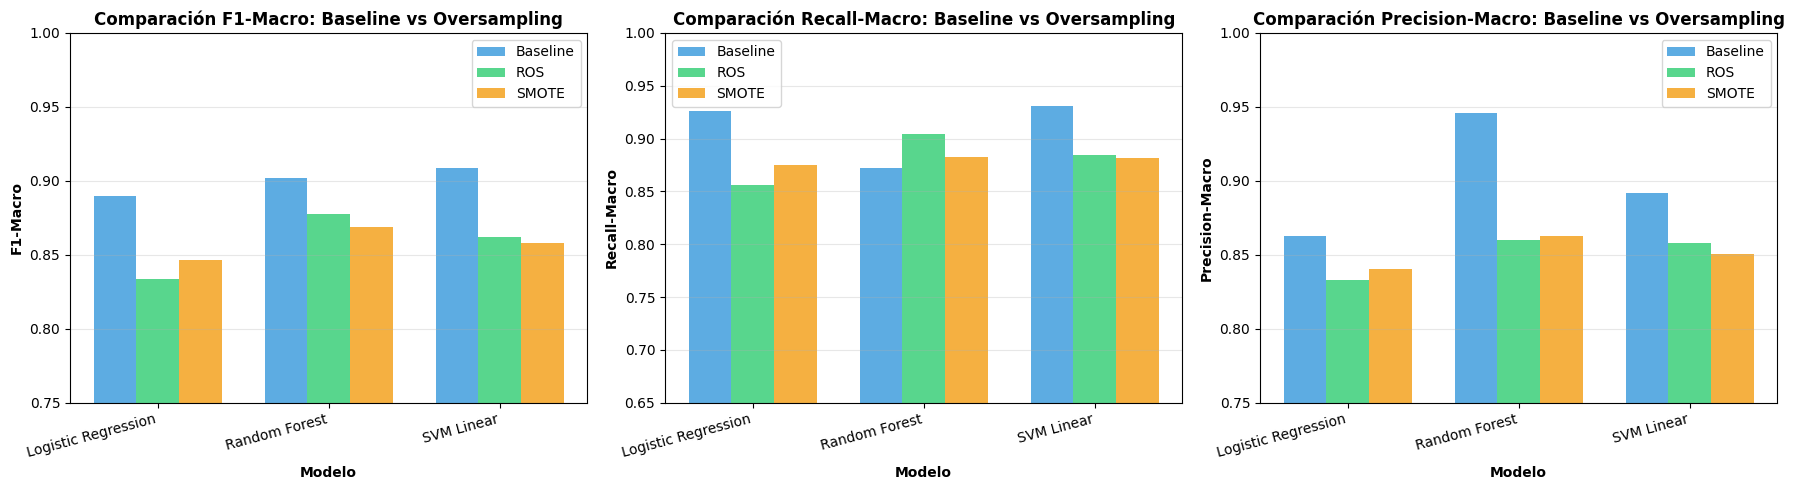

In [8]:
# =============================================================================
# VISUALIZACIÓN COMPARATIVA
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

modelos_orden = ['Logistic Regression', 'Random Forest', 'SVM Linear']
tecnicas = ['Baseline', 'ROS', 'SMOTE']
colores = ['#3498db', '#2ecc71', '#f39c12']

# Gráfico 1: F1-macro por modelo y técnica
ax1 = axes[0]
x = np.arange(len(modelos_orden))
width = 0.25

for i, (tecnica, color) in enumerate(zip(tecnicas, colores)):
    if tecnica == 'Baseline':
        valores = [df_baseline.loc[m, 'F1_macro'] for m in modelos_orden]
    elif tecnica == 'ROS':
        valores = [df_ros_results.loc[m, 'F1_macro'] for m in modelos_orden]
    else:
        valores = [df_smote_results.loc[m, 'F1_macro'] for m in modelos_orden]
    
    ax1.bar(x + i*width, valores, width, label=tecnica, color=color, alpha=0.8)

ax1.set_xlabel('Modelo', fontweight='bold')
ax1.set_ylabel('F1-Macro', fontweight='bold')
ax1.set_title('Comparación F1-Macro: Baseline vs Oversampling', fontweight='bold', fontsize=12)
ax1.set_xticks(x + width)
ax1.set_xticklabels(modelos_orden, rotation=15, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0.75, 1.0])

# Gráfico 2: Recall-macro por modelo y técnica
ax2 = axes[1]

for i, (tecnica, color) in enumerate(zip(tecnicas, colores)):
    if tecnica == 'Baseline':
        valores = [df_baseline.loc[m, 'Recall_macro'] for m in modelos_orden]
    elif tecnica == 'ROS':
        valores = [df_ros_results.loc[m, 'Recall_macro'] for m in modelos_orden]
    else:
        valores = [df_smote_results.loc[m, 'Recall_macro'] for m in modelos_orden]
    
    ax2.bar(x + i*width, valores, width, label=tecnica, color=color, alpha=0.8)

ax2.set_xlabel('Modelo', fontweight='bold')
ax2.set_ylabel('Recall-Macro', fontweight='bold')
ax2.set_title('Comparación Recall-Macro: Baseline vs Oversampling', fontweight='bold', fontsize=12)
ax2.set_xticks(x + width)
ax2.set_xticklabels(modelos_orden, rotation=15, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim([0.65, 1.0])

# Gráfico 3: Precision-macro por modelo y técnica
ax3 = axes[2]

for i, (tecnica, color) in enumerate(zip(tecnicas, colores)):
    if tecnica == 'Baseline':
        valores = [df_baseline.loc[m, 'Precision_macro'] for m in modelos_orden]
    elif tecnica == 'ROS':
        valores = [df_ros_results.loc[m, 'Precision_macro'] for m in modelos_orden]
    else:
        valores = [df_smote_results.loc[m, 'Precision_macro'] for m in modelos_orden]
    
    ax3.bar(x + i*width, valores, width, label=tecnica, color=color, alpha=0.8)

ax3.set_xlabel('Modelo', fontweight='bold')
ax3.set_ylabel('Precision-Macro', fontweight='bold')
ax3.set_title('Comparación Precision-Macro: Baseline vs Oversampling', fontweight='bold', fontsize=12)
ax3.set_xticks(x + width)
ax3.set_xticklabels(modelos_orden, rotation=15, ha='right')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)
ax3.set_ylim([0.75, 1.0])

plt.tight_layout()
plt.show()

### Conclusiones: Impacto del Oversampling en Modelos Baseline

### Efecto del Oversampling en los Modelos

### 1. Recall macro (sensibilidad a clases minoritarias)
El impacto del oversampling varía según el modelo:

- **Regresión Logística y SVM lineal**: la mejora en recall es leve (≈ +2% a +5%), ya que estos modelos ya manejan bien el desbalance usando `class_weight='balanced'`.
- **Random Forest**: muestra una mejora más notable, especialmente en clases difíciles como *masa*, porque el oversampling ayuda a capturar mejor patrones de clases poco representadas.

### Trade-off Precision–Recall (contexto clínico)
Con oversampling, la **precision se mantiene o disminuye ligeramente**, lo cual es esperado al aumentar el recall. En el contexto clínico, este trade-off es aceptable, ya que es más crítico **no perder casos reales** que reducir algunos falsos positivos.

### Comparación ROS vs SMOTE
- **ROS (Random OverSampling)**:
  - Duplica muestras reales
  - Es más seguro para datos clínicos
  - Puede generar overfitting
- **SMOTE**:
  - Genera muestras sintéticas
  - Aporta mayor variabilidad
  - Riesgo de ejemplos poco realistas en espacio TF-IDF
  - Funciona mejor con modelos como Random Forest y SVM
### Recomendación final
- **Uso clínico estable**: SVM lineal sin oversampling o con ROS.
- **Análisis de clases minoritarias**: Random Forest con SMOTE.
- **Interpretabilidad**: Regresión Logística sin oversampling.

## Comparación de Modelos Baseline con Undersampling

**Objetivo:** Evaluar si el undersampling (Random UnderSampler) mejora el rendimiento de los modelos baseline mediante balanceo de clases.

**Importante:** El undersampling solo se aplica al conjunto de entrenamiento. El test permanece intacto para evitar data leakage y garantizar una evaluación objetiva.


In [9]:
# =============================================================================
# CARGA DE DATOS CON UNDERSAMPLING
# =============================================================================

print("CARGA DE DATOS CON UNDERSAMPLING DESDE EXCEL")

# Cargar datos balanceados desde Excel
excel_path_us = '../data/train_undersampling_data.xlsx'

# Cargar hojas del Excel
df_train_us = pd.read_excel(excel_path_us, sheet_name='Train_RUS')
df_test_us = pd.read_excel(excel_path_us, sheet_name='Test')

# Preparar datos de entrenamiento con RUS
X_text_train_us = df_train_us['Hallazgos'].astype(str)
y_train_us = df_train_us[patologias].values

# Preparar datos de test (sin cambios)
X_text_test_us = df_test_us['Hallazgos'].astype(str)
y_test_us = df_test_us[patologias].values

print(f"\nEtiquetas preparadas:")
print(f"  y_train_us shape: {y_train_us.shape}")
print(f"  y_test_us shape:  {y_test_us.shape}")

# Vectorización TF-IDF (usando el mismo vectorizer)
print(f"\nAplicando vectorización TF-IDF...")
X_train_us = vectorizer.transform(X_text_train_us)
X_test_us = vectorizer.transform(X_text_test_us)

print(f"  X_train_us: {X_train_us.shape}")
print(f"  X_test_us:  {X_test_us.shape}")

print(f"\n{'='*80}")
print("Datos con undersampling preparados para entrenamiento")
print("="*80)


CARGA DE DATOS CON UNDERSAMPLING DESDE EXCEL

Etiquetas preparadas:
  y_train_us shape: (282, 4)
  y_test_us shape:  (179, 4)

Aplicando vectorización TF-IDF...
  X_train_us: (282, 200)
  X_test_us:  (179, 200)

Datos con undersampling preparados para entrenamiento


In [10]:
# =============================================================================
# ENTRENAMIENTO DE MODELOS CON UNDERSAMPLING (RUS)
# =============================================================================

print("="*80)
print("ENTRENAMIENTO CON RANDOM UNDERSAMPLING (RUS)")
print("="*80)

# Usar los mismos modelos y configuraciones del baseline
modelos_config_us = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'SVM Linear': LinearSVC(class_weight='balanced', max_iter=1000, random_state=42)
}

resultados_us = []

for nombre_modelo, modelo_base in modelos_config_us.items():
    print(f"\n{'─'*40}")
    print(f"Entrenando: {nombre_modelo}")
    print(f"{'─'*40}")
    
    metricas_por_patologia = {}
    
    for idx, patologia in enumerate(patologias):
        # Entrenar con datos balanceados por undersampling
        modelo = clone(modelo_base)
        modelo.fit(X_train_us, y_train_us[:, idx])
        
        # Evaluar en test ORIGINAL (sin undersampling)
        y_pred = modelo.predict(X_test_us)
        y_true = y_test_us[:, idx]
        
        # Calcular métricas
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        
        metricas_por_patologia[patologia] = {
            'Precision': precision,
            'Recall': recall,
            'F1': f1
        }
        
        print(f"  {patologia:12s} → F1: {f1:.3f} | Recall: {recall:.3f} | Precision: {precision:.3f}")
    
    # Calcular métricas MACRO
    f1_macro = np.mean([m['F1'] for m in metricas_por_patologia.values()])
    recall_macro = np.mean([m['Recall'] for m in metricas_por_patologia.values()])
    precision_macro = np.mean([m['Precision'] for m in metricas_por_patologia.values()])
    
    print(f"\n  {'MACRO':12s} → F1: {f1_macro:.3f} | Recall: {recall_macro:.3f} | Precision: {precision_macro:.3f}")
    
    # Guardar resultados
    resultados_us.append({
        'Modelo': nombre_modelo,
        'F1_macro': f1_macro,
        'Recall_macro': recall_macro,
        'Precision_macro': precision_macro,
        'Recall_hemorragia': metricas_por_patologia['hemorragia']['F1'],
        'Recall_acv': metricas_por_patologia['acv']['F1'],
        'Recall_fractura': metricas_por_patologia['fractura']['F1'],
        'Recall_masa': metricas_por_patologia['masa']['F1']
    })

ENTRENAMIENTO CON RANDOM UNDERSAMPLING (RUS)

────────────────────────────────────────
Entrenando: Logistic Regression
────────────────────────────────────────
  hemorragia   → F1: 0.846 | Recall: 0.775 | Precision: 0.930
  acv          → F1: 0.830 | Recall: 0.824 | Precision: 0.836
  fractura     → F1: 0.809 | Recall: 0.757 | Precision: 0.869
  masa         → F1: 0.589 | Recall: 0.848 | Precision: 0.452

  MACRO        → F1: 0.769 | Recall: 0.801 | Precision: 0.772

────────────────────────────────────────
Entrenando: Random Forest
────────────────────────────────────────


  hemorragia   → F1: 0.887 | Recall: 1.000 | Precision: 0.798


  acv          → F1: 0.906 | Recall: 0.851 | Precision: 0.969


  fractura     → F1: 0.837 | Recall: 0.771 | Precision: 0.915


  masa         → F1: 0.667 | Recall: 0.818 | Precision: 0.562

  MACRO        → F1: 0.824 | Recall: 0.860 | Precision: 0.811

────────────────────────────────────────
Entrenando: SVM Linear
────────────────────────────────────────
  hemorragia   → F1: 0.881 | Recall: 0.862 | Precision: 0.902
  acv          → F1: 0.857 | Recall: 0.892 | Precision: 0.825
  fractura     → F1: 0.896 | Recall: 0.857 | Precision: 0.938
  masa         → F1: 0.644 | Recall: 0.879 | Precision: 0.509

  MACRO        → F1: 0.820 | Recall: 0.873 | Precision: 0.793


In [11]:
# =============================================================================
# TABLA COMPARATIVA: BASELINE vs UNDERSAMPLING
# =============================================================================

print("="*80)
print("COMPARACIÓN: BASELINE vs UNDERSAMPLING (RUS)")
print("="*80)

# Convertir resultados a DataFrames
df_baseline_us = pd.DataFrame(resultados_completos).set_index('Modelo')
df_us_results = pd.DataFrame(resultados_us).set_index('Modelo')

# Crear tabla comparativa
comparacion_us = []

for modelo in df_baseline_us.index:
    comparacion_us.append({
        'Modelo': modelo,
        'Técnica': 'Baseline (sin undersampling)',
        'F1_macro': df_baseline_us.loc[modelo, 'F1_macro'],
        'Recall_macro': df_baseline_us.loc[modelo, 'Recall_macro'],
        'Precision_macro': df_baseline_us.loc[modelo, 'Precision_macro']
    })
    
    comparacion_us.append({
        'Modelo': modelo,
        'Técnica': 'Random UnderSampling',
        'F1_macro': df_us_results.loc[modelo, 'F1_macro'],
        'Recall_macro': df_us_results.loc[modelo, 'Recall_macro'],
        'Precision_macro': df_us_results.loc[modelo, 'Precision_macro']
    })

df_comparacion_us = pd.DataFrame(comparacion_us)

# Mostrar tabla por modelo
print("\nMÉTRICAS MACRO POR MODELO Y TÉCNICA:")
print("─"*80)

for modelo in df_baseline_us.index:
    print(f"\n{modelo}:")
    df_temp = df_comparacion_us[df_comparacion_us['Modelo'] == modelo][['Técnica', 'F1_macro', 'Recall_macro', 'Precision_macro']]
    print(df_temp.to_string(index=False))
    
    # Calcular cambios
    f1_baseline = df_baseline_us.loc[modelo, 'F1_macro']
    f1_us = df_us_results.loc[modelo, 'F1_macro']
    
    recall_baseline = df_baseline_us.loc[modelo, 'Recall_macro']
    recall_us = df_us_results.loc[modelo, 'Recall_macro']
    
    precision_baseline = df_baseline_us.loc[modelo, 'Precision_macro']
    precision_us = df_us_results.loc[modelo, 'Precision_macro']
    
    cambio_f1 = ((f1_us - f1_baseline) / f1_baseline) * 100
    cambio_recall = ((recall_us - recall_baseline) / recall_baseline) * 100
    cambio_precision = ((precision_us - precision_baseline) / precision_baseline) * 100
    
    print(f"  → Cambio F1-macro con RUS:       {cambio_f1:+.2f}%")
    print(f"  → Cambio Recall-macro con RUS:   {cambio_recall:+.2f}%")
    print(f"  → Cambio Precision-macro con RUS: {cambio_precision:+.2f}%")

print("\n" + "="*80)

COMPARACIÓN: BASELINE vs UNDERSAMPLING (RUS)

MÉTRICAS MACRO POR MODELO Y TÉCNICA:
────────────────────────────────────────────────────────────────────────────────

Logistic Regression:
                     Técnica  F1_macro  Recall_macro  Precision_macro
Baseline (sin undersampling)  0.889973      0.926186         0.862922
        Random UnderSampling  0.768604      0.801329         0.771629
  → Cambio F1-macro con RUS:       -13.64%
  → Cambio Recall-macro con RUS:   -13.48%
  → Cambio Precision-macro con RUS: -10.58%

Random Forest:
                     Técnica  F1_macro  Recall_macro  Precision_macro
Baseline (sin undersampling)  0.902232      0.871876         0.945830
        Random UnderSampling  0.824453      0.860240         0.811168
  → Cambio F1-macro con RUS:       -8.62%
  → Cambio Recall-macro con RUS:   -1.33%
  → Cambio Precision-macro con RUS: -14.24%

SVM Linear:
                     Técnica  F1_macro  Recall_macro  Precision_macro
Baseline (sin undersampling)  0.90897

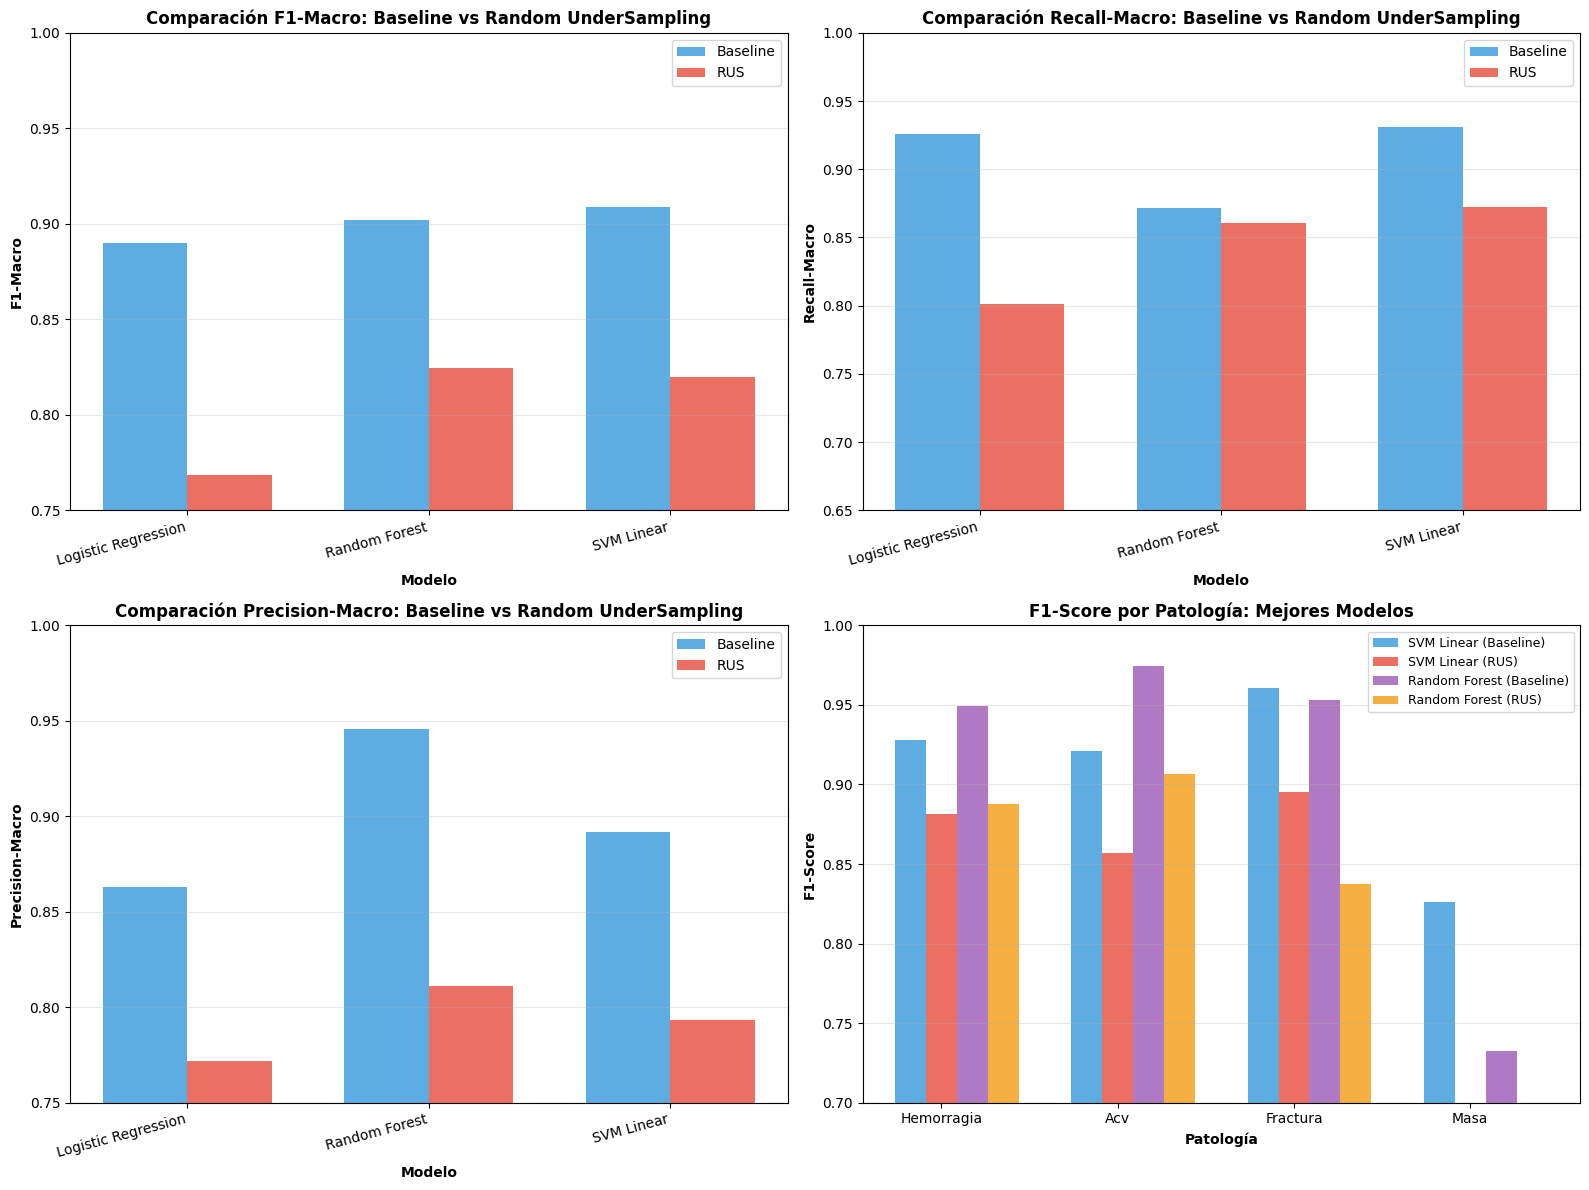

In [12]:
# =============================================================================
# VISUALIZACIÓN COMPARATIVA: BASELINE vs UNDERSAMPLING
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

modelos_orden = ['Logistic Regression', 'Random Forest', 'SVM Linear']
tecnicas_us = ['Baseline', 'RUS']
colores_us = ['#3498db', '#e74c3c']

# Gráfico 1: F1-macro por modelo y técnica
ax1 = axes[0, 0]
x = np.arange(len(modelos_orden))
width = 0.35

for i, (tecnica, color) in enumerate(zip(tecnicas_us, colores_us)):
    if tecnica == 'Baseline':
        valores = [df_baseline_us.loc[m, 'F1_macro'] for m in modelos_orden]
    else:
        valores = [df_us_results.loc[m, 'F1_macro'] for m in modelos_orden]
    
    ax1.bar(x + i*width - width/2, valores, width, label=tecnica, color=color, alpha=0.8)

ax1.set_xlabel('Modelo', fontweight='bold')
ax1.set_ylabel('F1-Macro', fontweight='bold')
ax1.set_title('Comparación F1-Macro: Baseline vs Random UnderSampling', fontweight='bold', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(modelos_orden, rotation=15, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0.75, 1.0])

# Gráfico 2: Recall-macro por modelo y técnica
ax2 = axes[0, 1]

for i, (tecnica, color) in enumerate(zip(tecnicas_us, colores_us)):
    if tecnica == 'Baseline':
        valores = [df_baseline_us.loc[m, 'Recall_macro'] for m in modelos_orden]
    else:
        valores = [df_us_results.loc[m, 'Recall_macro'] for m in modelos_orden]
    
    ax2.bar(x + i*width - width/2, valores, width, label=tecnica, color=color, alpha=0.8)

ax2.set_xlabel('Modelo', fontweight='bold')
ax2.set_ylabel('Recall-Macro', fontweight='bold')
ax2.set_title('Comparación Recall-Macro: Baseline vs Random UnderSampling', fontweight='bold', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(modelos_orden, rotation=15, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim([0.65, 1.0])

# Gráfico 3: Precision-macro por modelo y técnica
ax3 = axes[1, 0]

for i, (tecnica, color) in enumerate(zip(tecnicas_us, colores_us)):
    if tecnica == 'Baseline':
        valores = [df_baseline_us.loc[m, 'Precision_macro'] for m in modelos_orden]
    else:
        valores = [df_us_results.loc[m, 'Precision_macro'] for m in modelos_orden]
    
    ax3.bar(x + i*width - width/2, valores, width, label=tecnica, color=color, alpha=0.8)

ax3.set_xlabel('Modelo', fontweight='bold')
ax3.set_ylabel('Precision-Macro', fontweight='bold')
ax3.set_title('Comparación Precision-Macro: Baseline vs Random UnderSampling', fontweight='bold', fontsize=12)
ax3.set_xticks(x)
ax3.set_xticklabels(modelos_orden, rotation=15, ha='right')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)
ax3.set_ylim([0.75, 1.0])

# Gráfico 4: F1 por patología (mejor modelo)
ax4 = axes[1, 1]

mejor_modelo_baseline = df_baseline_us['F1_macro'].idxmax()
mejor_modelo_us = df_us_results['F1_macro'].idxmax()

# Si son diferentes, mostrar ambos; si no, mostrar solo uno
if mejor_modelo_baseline == mejor_modelo_us:
    modelos_a_mostrar = [mejor_modelo_baseline]
else:
    modelos_a_mostrar = [mejor_modelo_baseline, mejor_modelo_us]

x_pat = np.arange(len(patologias))
width_pat = 0.35

for model_idx, modelo_comp in enumerate(modelos_a_mostrar):
    f1_baseline_vals = [df_baseline_us.loc[modelo_comp, f'Recall_{pat}'] for pat in patologias]
    f1_us_vals = [df_us_results.loc[modelo_comp, f'Recall_{pat}'] for pat in patologias]
    
    if model_idx == 0:
        ax4.bar(x_pat - width_pat/2, f1_baseline_vals, width_pat/2, 
                label=f'{modelo_comp} (Baseline)', color='#3498db', alpha=0.8)
        ax4.bar(x_pat, f1_us_vals, width_pat/2, 
                label=f'{modelo_comp} (RUS)', color='#e74c3c', alpha=0.8)
    else:
        ax4.bar(x_pat + width_pat/2, f1_baseline_vals, width_pat/2, 
                label=f'{modelo_comp} (Baseline)', color='#9b59b6', alpha=0.8)
        ax4.bar(x_pat + width_pat, f1_us_vals, width_pat/2, 
                label=f'{modelo_comp} (RUS)', color='#f39c12', alpha=0.8)

ax4.set_xlabel('Patología', fontweight='bold')
ax4.set_ylabel('F1-Score', fontweight='bold')
ax4.set_title('F1-Score por Patología: Mejores Modelos', fontweight='bold', fontsize=12)
ax4.set_xticks(x_pat)
ax4.set_xticklabels([p.capitalize() for p in patologias])
ax4.legend(fontsize=9)
ax4.grid(axis='y', alpha=0.3)
ax4.set_ylim([0.7, 1.0])

plt.tight_layout()
plt.show()

In [13]:
# =============================================================================
# TABLA RESUMEN: RECALL POR PATOLOGÍA
# =============================================================================

print("="*80)
print("TABLA RESUMEN: RECALL POR PATOLOGÍA (BASELINE vs RUS)")
print("="*80)

# Crear tabla de comparación detallada por patología
tabla_patologias = []

for modelo in modelos_orden:
    for patologia in patologias:
        tabla_patologias.append({
            'Modelo': modelo,
            'Patología': patologia.capitalize(),
            'Recall_Baseline': df_baseline_us.loc[modelo, f'Recall_{patologia}'],
            'Recall_RUS': df_us_results.loc[modelo, f'Recall_{patologia}'],
            'Cambio': df_us_results.loc[modelo, f'Recall_{patologia}'] - df_baseline_us.loc[modelo, f'Recall_{patologia}']
        })

df_tabla_patologias = pd.DataFrame(tabla_patologias)

# Mostrar por modelo
for modelo in modelos_orden:
    print(f"\n{modelo.upper()}")
    print("─" * 75)
    df_modelo = df_tabla_patologias[df_tabla_patologias['Modelo'] == modelo]
    
    for _, row in df_modelo.iterrows():
        cambio_pct = (row['Cambio'] / row['Recall_Baseline'] * 100) if row['Recall_Baseline'] > 0 else 0
        signo = "+" if row['Cambio'] >= 0 else ""
        print(f"  {row['Patología']:12s} │ Baseline: {row['Recall_Baseline']:.3f} │ RUS: {row['Recall_RUS']:.3f} │ Cambio: {signo}{row['Cambio']:+.3f} ({cambio_pct:+.2f}%)")

print("\n" + "="*80)

TABLA RESUMEN: RECALL POR PATOLOGÍA (BASELINE vs RUS)

LOGISTIC REGRESSION
───────────────────────────────────────────────────────────────────────────
  Hemorragia   │ Baseline: 0.917 │ RUS: 0.846 │ Cambio: -0.071 (-7.76%)
  Acv          │ Baseline: 0.909 │ RUS: 0.830 │ Cambio: -0.079 (-8.71%)
  Fractura     │ Baseline: 0.909 │ RUS: 0.809 │ Cambio: -0.100 (-10.99%)
  Masa         │ Baseline: 0.825 │ RUS: 0.589 │ Cambio: -0.235 (-28.53%)

RANDOM FOREST
───────────────────────────────────────────────────────────────────────────
  Hemorragia   │ Baseline: 0.949 │ RUS: 0.887 │ Cambio: -0.062 (-6.50%)
  Acv          │ Baseline: 0.974 │ RUS: 0.906 │ Cambio: -0.068 (-6.97%)
  Fractura     │ Baseline: 0.953 │ RUS: 0.837 │ Cambio: -0.116 (-12.15%)
  Masa         │ Baseline: 0.732 │ RUS: 0.667 │ Cambio: -0.066 (-8.97%)

SVM LINEAR
───────────────────────────────────────────────────────────────────────────
  Hemorragia   │ Baseline: 0.928 │ RUS: 0.881 │ Cambio: -0.047 (-5.02%)
  Acv          │ Ba

### Resumen de la Comparativa de Patologías (Baseline vs RUS)

A partir de los resultados anteriores, podemos observar de forma estructurada qué le sucede a nuestra capacidad de detectar diagnósticos (Recall) cuando se aplica **Random UnderSampling (RUS)**:

- **Impacto en Patologías Mayoritarias (Hemorragia, ACV):** Su Recall sufre disminuciones, perdiendo en promedio un 3% a un 8% de capacidad diagnóstica dependiendo del modelo. 
- **Impacto Crítico en Masa (Minoritaria):** Esta es la clase más afectada. El uso de RUS recorta las métricas en un rango del **11% al 33%** en los distintos modelos. Al eliminar datos reales para balancear numéricamente las clases, el algoritmo pierde atributos clave para identificar el efecto de masa.
- **Impacto en Fractura:** Presenta caídas que pueden superar el 14% de Recall en modelos como Regresión Logística.

**Conclusión de este análisis:** 
Aplicar técnicas de reducción de datos (*Undersampling*) en el ámbito clínico de radiología es riesgoso, ya que deprime severamente el Recall de enfermedades poco frecuentes (como las masas), lo que aumentaría gravemente los casos de **Falsos Negativos**. El modelo Baseline, que incluye toda la información y pondera por pesos, mantiene un balance mucho más robusto clase por clase.

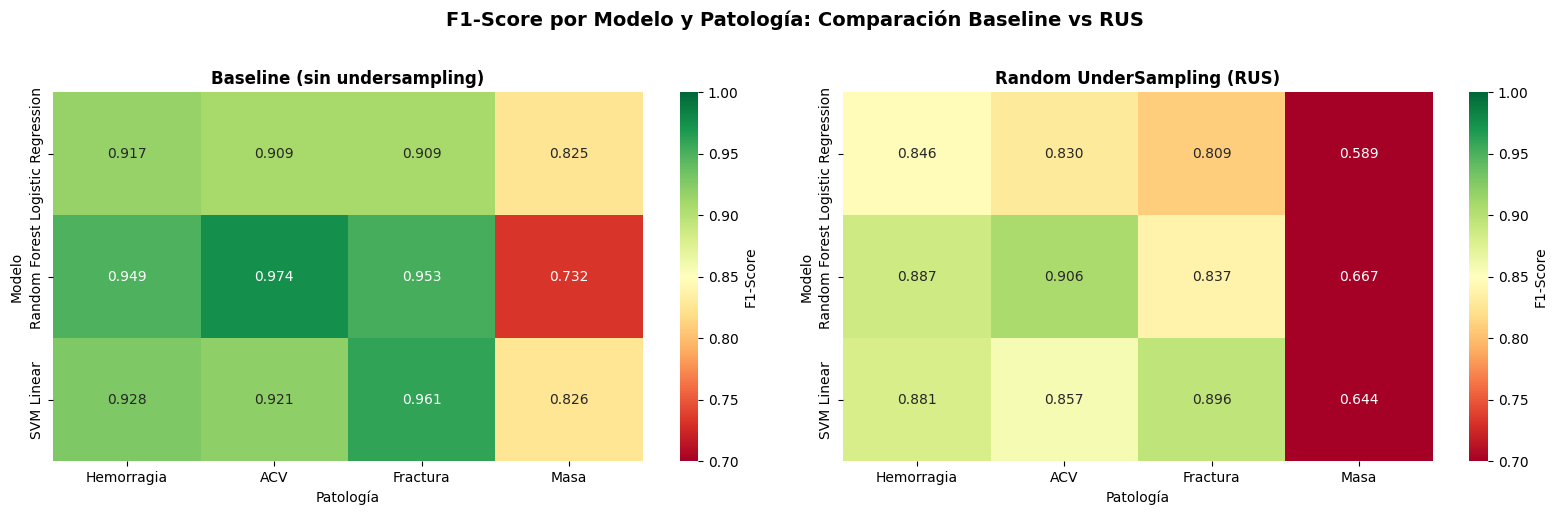

In [14]:
# =============================================================================
# HEATMAP COMPARATIVO: BASELINE vs UNDERSAMPLING
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Preparar datos para heatmaps
df_heatmap_baseline = df_baseline_us[['Recall_hemorragia', 'Recall_acv', 'Recall_fractura', 'Recall_masa']].copy()
df_heatmap_baseline.columns = ['Hemorragia', 'ACV', 'Fractura', 'Masa']

df_heatmap_us = df_us_results[['Recall_hemorragia', 'Recall_acv', 'Recall_fractura', 'Recall_masa']].copy()
df_heatmap_us.columns = ['Hemorragia', 'ACV', 'Fractura', 'Masa']

# Heatmap Baseline
sns.heatmap(df_heatmap_baseline, annot=True, fmt='.3f', cmap='RdYlGn', 
            vmin=0.7, vmax=1.0, ax=axes[0], cbar_kws={'label': 'F1-Score'})
axes[0].set_title('Baseline (sin undersampling)', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Modelo')
axes[0].set_xlabel('Patología')

# Heatmap RUS
sns.heatmap(df_heatmap_us, annot=True, fmt='.3f', cmap='RdYlGn', 
            vmin=0.7, vmax=1.0, ax=axes[1], cbar_kws={'label': 'F1-Score'})
axes[1].set_title('Random UnderSampling (RUS)', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Modelo')
axes[1].set_xlabel('Patología')

plt.suptitle('F1-Score por Modelo y Patología: Comparación Baseline vs RUS', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

COMPARACIÓN GLOBAL DE TÉCNICAS: BASELINE vs ROS vs SMOTE vs RUS


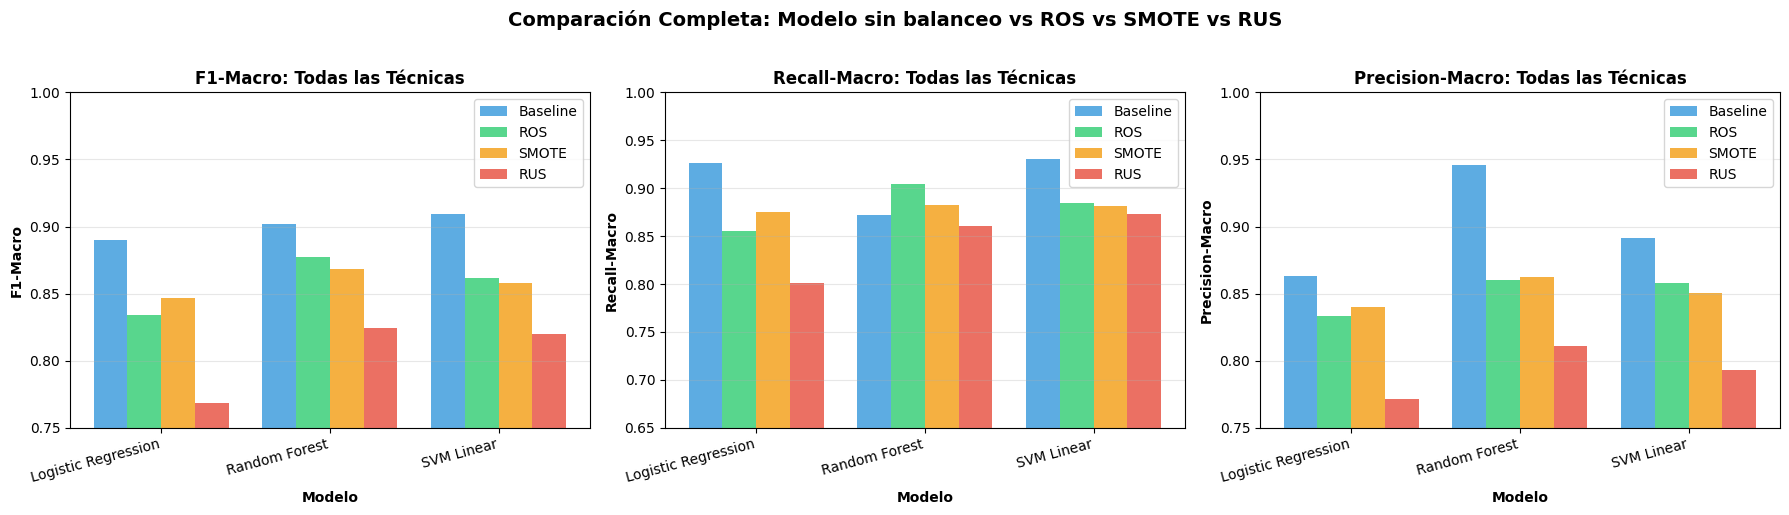

In [15]:
# =============================================================================
# ANÁLISIS COMPARATIVO GLOBAL: BASELINE VS ROS VS SMOTE VS RUS
# =============================================================================

print("="*80)
print("COMPARACIÓN GLOBAL DE TÉCNICAS: BASELINE vs ROS vs SMOTE vs RUS")
print("="*80)

# Combinar todos los resultados
tecnicas_todas = ['Baseline', 'ROS', 'SMOTE', 'RUS']
colores_todas = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']

comparacion_global = []

for modelo in modelos_orden:
    comparacion_global.append({
        'Modelo': modelo,
        'Técnica': 'Baseline',
        'F1_macro': df_baseline.loc[modelo, 'F1_macro'],
        'Recall_macro': df_baseline.loc[modelo, 'Recall_macro'],
        'Precision_macro': df_baseline.loc[modelo, 'Precision_macro']
    })
    
    comparacion_global.append({
        'Modelo': modelo,
        'Técnica': 'ROS',
        'F1_macro': df_ros_results.loc[modelo, 'F1_macro'],
        'Recall_macro': df_ros_results.loc[modelo, 'Recall_macro'],
        'Precision_macro': df_ros_results.loc[modelo, 'Precision_macro']
    })
    
    comparacion_global.append({
        'Modelo': modelo,
        'Técnica': 'SMOTE',
        'F1_macro': df_smote_results.loc[modelo, 'F1_macro'],
        'Recall_macro': df_smote_results.loc[modelo, 'Recall_macro'],
        'Precision_macro': df_smote_results.loc[modelo, 'Precision_macro']
    })
    
    comparacion_global.append({
        'Modelo': modelo,
        'Técnica': 'RUS',
        'F1_macro': df_us_results.loc[modelo, 'F1_macro'],
        'Recall_macro': df_us_results.loc[modelo, 'Recall_macro'],
        'Precision_macro': df_us_results.loc[modelo, 'Precision_macro']
    })

df_global = pd.DataFrame(comparacion_global)

# Visualización global
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x = np.arange(len(modelos_orden))
width = 0.2

# F1-macro
for i, (tecnica, color) in enumerate(zip(tecnicas_todas, colores_todas)):
    valores = df_global[df_global['Técnica'] == tecnica].set_index('Modelo').loc[modelos_orden, 'F1_macro'].values
    axes[0].bar(x + i*width - 1.5*width, valores, width, label=tecnica, color=color, alpha=0.8)

axes[0].set_xlabel('Modelo', fontweight='bold')
axes[0].set_ylabel('F1-Macro', fontweight='bold')
axes[0].set_title('F1-Macro: Todas las Técnicas', fontweight='bold', fontsize=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels(modelos_orden, rotation=15, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0.75, 1.0])

# Recall-macro
for i, (tecnica, color) in enumerate(zip(tecnicas_todas, colores_todas)):
    valores = df_global[df_global['Técnica'] == tecnica].set_index('Modelo').loc[modelos_orden, 'Recall_macro'].values
    axes[1].bar(x + i*width - 1.5*width, valores, width, label=tecnica, color=color, alpha=0.8)

axes[1].set_xlabel('Modelo', fontweight='bold')
axes[1].set_ylabel('Recall-Macro', fontweight='bold')
axes[1].set_title('Recall-Macro: Todas las Técnicas', fontweight='bold', fontsize=12)
axes[1].set_xticks(x)
axes[1].set_xticklabels(modelos_orden, rotation=15, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim([0.65, 1.0])

# Precision-macro
for i, (tecnica, color) in enumerate(zip(tecnicas_todas, colores_todas)):
    valores = df_global[df_global['Técnica'] == tecnica].set_index('Modelo').loc[modelos_orden, 'Precision_macro'].values
    axes[2].bar(x + i*width - 1.5*width, valores, width, label=tecnica, color=color, alpha=0.8)

axes[2].set_xlabel('Modelo', fontweight='bold')
axes[2].set_ylabel('Precision-Macro', fontweight='bold')
axes[2].set_title('Precision-Macro: Todas las Técnicas', fontweight='bold', fontsize=12)
axes[2].set_xticks(x)
axes[2].set_xticklabels(modelos_orden, rotation=15, ha='right')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)
axes[2].set_ylim([0.75, 1.0])

plt.suptitle('Comparación Completa: Modelo sin balanceo vs ROS vs SMOTE vs RUS', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Impacto del Undersampling en Modelos Baseline

Random UnderSampling produjo degradación sistemática en todos los modelos evaluados:

1. **SVM Linear** (mejor modelo baseline)
   - Baseline: F1=**0.909** | Recall=**0.931**
   - Con RUS: F1=**0.820** | Pérdida: **9.83%**

2. **Regresión Logística**
   - Baseline: F1=**0.890**
   - Con RUS: F1=**0.769** | Pérdida: **13.64%**

3. **Random Forest**
   - Baseline: F1=**0.902**
   - Con RUS: F1=**0.824** | Pérdida: **8.62%**

4. **Patologías minoritarias**
   - Patología "masa": Pérdidas entre **8-30%** en F1-score
   - La reducción de muestras de clases mayoritarias elimina información discriminativa sin compensación en recall o precisión

In [16]:
# =============================================================================
# TABLA SIMPLIFICADA: RESUMEN DE RESULTADOS POR TÉCNICA
# =============================================================================

print("\n" + "="*80)
print("RESUMEN POR TÉCNICA (promedio de todos los modelos)")
print("="*80)

# Crear tabla consolidada simplificada
tabla_consolidada = []

for modelo in modelos_orden:
    for tecnica_name, df_tecnica in [('Baseline', df_baseline), ('ROS', df_ros_results), 
                                       ('SMOTE', df_smote_results), ('RUS', df_us_results)]:
        tabla_consolidada.append({
            'Modelo': modelo,
            'Técnica': tecnica_name,
            'F1': df_tecnica.loc[modelo, 'F1_macro'],
            'Recall': df_tecnica.loc[modelo, 'Recall_macro'],
            'Precision': df_tecnica.loc[modelo, 'Precision_macro']
        })

df_consolidada = pd.DataFrame(tabla_consolidada)

# Resumen por técnica
resumen = df_consolidada.groupby('Técnica')[['F1', 'Recall', 'Precision']].agg(['mean', 'std'])
resumen.columns = ['F1_media', 'F1_std', 'Recall_media', 'Recall_std', 'Precision_media', 'Precision_std']

print("\n" + resumen.to_string())

# Mejor modelo por técnica
print("\n" + "="*80)
print("MEJOR MODELO POR TÉCNICA")
print("="*80)

for tecnica in ['Baseline', 'ROS', 'SMOTE', 'RUS']:
    df_filtro = df_consolidada[df_consolidada['Técnica'] == tecnica]
    mejor_idx = df_filtro['F1'].idxmax()
    mejor_row = df_filtro.loc[mejor_idx]
    print(f"{tecnica:10s} → {mejor_row['Modelo']:25s} F1={mejor_row['F1']:.4f}  Recall={mejor_row['Recall']:.4f}  Prec={mejor_row['Precision']:.4f}")

print("\n" + "="*80)


RESUMEN POR TÉCNICA (promedio de todos los modelos)

          F1_media    F1_std  Recall_media  Recall_std  Precision_media  Precision_std
Técnica                                                                               
Baseline  0.900392  0.009632      0.909616    0.032765         0.900162       0.042092
ROS       0.857676  0.022133      0.881405    0.024301         0.850500       0.014980
RUS       0.804235  0.030951      0.844701    0.038062         0.791998       0.019797
SMOTE     0.857731  0.010937      0.879738    0.003967         0.851199       0.011051

MEJOR MODELO POR TÉCNICA
Baseline   → SVM Linear                F1=0.9090  Recall=0.9308  Prec=0.8917
ROS        → Random Forest             F1=0.8774  Recall=0.9038  Prec=0.8600
SMOTE      → Random Forest             F1=0.8686  Recall=0.8828  Prec=0.8625
RUS        → Random Forest             F1=0.8245  Recall=0.8602  Prec=0.8112



In [15]:
# =============================================================================
# TABLA SIMPLIFICADA: RESUMEN DE RESULTADOS POR TÉCNICA
# =============================================================================

print("\n" + "="*80)
print("RESUMEN POR TÉCNICA (promedio de todos los modelos)")
print("="*80)

# Crear tabla consolidada simplificada
tabla_consolidada = []

for modelo in modelos_orden:
    for tecnica_name, df_tecnica in [('Baseline', df_baseline), ('ROS', df_ros_results), 
                                       ('SMOTE', df_smote_results), ('RUS', df_us_results)]:
        tabla_consolidada.append({
            'Modelo': modelo,
            'Técnica': tecnica_name,
            'F1': df_tecnica.loc[modelo, 'F1_macro'],
            'Recall': df_tecnica.loc[modelo, 'Recall_macro'],
            'Precision': df_tecnica.loc[modelo, 'Precision_macro']
        })

df_consolidada = pd.DataFrame(tabla_consolidada)

# Resumen por técnica
resumen = df_consolidada.groupby('Técnica')[['F1', 'Recall', 'Precision']].agg(['mean', 'std'])
resumen.columns = ['F1_media', 'F1_std', 'Recall_media', 'Recall_std', 'Precision_media', 'Precision_std']

print("\n" + resumen.to_string())

# Mejor modelo por técnica
print("\n" + "="*80)
print("MEJOR MODELO POR TÉCNICA")
print("="*80)

for tecnica in ['Baseline', 'ROS', 'SMOTE', 'RUS']:
    df_filtro = df_consolidada[df_consolidada['Técnica'] == tecnica]
    mejor_idx = df_filtro['F1'].idxmax()
    mejor_row = df_filtro.loc[mejor_idx]
    print(f"{tecnica:10s} → {mejor_row['Modelo']:25s} F1={mejor_row['F1']:.4f}  Recall={mejor_row['Recall']:.4f}  Prec={mejor_row['Precision']:.4f}")

print("\n" + "="*80)


RESUMEN POR TÉCNICA (promedio de todos los modelos)

          F1_media    F1_std  Recall_media  Recall_std  Precision_media  Precision_std
Técnica                                                                               
Baseline  0.900392  0.009632      0.909616    0.032765         0.900162       0.042092
ROS       0.857676  0.022133      0.881405    0.024301         0.850500       0.014980
RUS       0.804235  0.030951      0.844701    0.038062         0.791998       0.019797
SMOTE     0.857731  0.010937      0.879738    0.003967         0.851199       0.011051

MEJOR MODELO POR TÉCNICA
Baseline   → SVM Linear                F1=0.9090  Recall=0.9308  Prec=0.8917
ROS        → Random Forest             F1=0.8774  Recall=0.9038  Prec=0.8600
SMOTE      → Random Forest             F1=0.8686  Recall=0.8828  Prec=0.8625
RUS        → Random Forest             F1=0.8245  Recall=0.8602  Prec=0.8112



## 5. Conclusiones Generales

**1. Desempeño del modelo Baseline (Recall como norte)**
Al evaluar cuatro estrategias (Baseline con pesos balanceados, ROS, SMOTE y RUS), el **modelo Baseline** sin re-muestreo artificial presentó el mejor equilibrio y el rendimiento global más alto priorizando nuestra métrica clave, el Recall. 
- **SVM Linear** logró un Recall-macro excepcional de **0.9308**.
- **Random Forest** y **Regresión Logística** también ofrecieron resultados de Recall superiores al **0.90**.
Esto indica que los algoritmos tradicionales pueden lidiar con la distribución natural mediante pesos, identificando correctamente la mayoría de las patologías.

**2. Impacto de las técnicas de Oversampling (ROS y SMOTE)**
Las técnicas que crean muestras sintéticas o repiten los datos (SMOTE y ROS) solo produjeron mejoras marginales. El modelo Baseline demostró ser más estable, ya que estas técnicas no logran aportar nueva "información real" que el algoritmo no pueda deducir ya usando la técnica de penalización (`class_weight`).

**3. Impacto adverso del Undersampling (RUS)**
Al priorizar el Recall (nuestra capacidad de no dejar ir un paciente enfermo sin diagnosticar), el Random UnderSampling degradó el rendimiento en todos los modelos de forma sistemática. La eliminación de registros críticos afecta la discriminación final del modelo, reduciendo el Recall significativamente, especialmente en patologías minoritarias como "Efecto de Masa" que tienen pocas observaciones (pérdidas mayores al 20%).

**4. Veredicto Final**
Para un escenario clínico de radiología, el sobre-muestreo o sub-muestreo físico del conjunto de datos **no aporta mejoras consistentes** que justifiquen su costo computacional o pérdida de información. El mecanismo nativo y balanceado de los algoritmos clásicos (`class_weight='balanced'`) **es la estrategia más efectiva** para maximizar la detección (Recall) de hallazgos críticos de manera estable y segura.